Connected to Python 3.13.2

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
# 1. LOAD DATA
TRAIN_PATH = "data/development_train.csv"
VALIDATION_PATH = "data/development_validation.csv"

train_df = pd.read_csv(TRAIN_PATH)
validation_df = pd.read_csv(VALIDATION_PATH)

print("=" * 60)
print("DATA TRUST ENGINE - INITIAL DATA ANALYSIS")
print("=" * 60)

DATA TRUST ENGINE - INITIAL DATA ANALYSIS


In [ ]:
# 2. BASIC DATASET INFORMATION
print("\n--- DATASET SHAPE ---")

print("Training data:")
print("Rows:", train_df.shape[0])
print("Columns:", train_df.shape[1])

print("\nValidation data:")
print("Rows:", validation_df.shape[0])
print("Columns:", validation_df.shape[1])


--- DATASET SHAPE ---
Training data:
Rows: 9800
Columns: 8

Validation data:
Rows: 2100
Columns: 8


In [ ]:
# 3. COLUMN NAMES
print("\n--- COLUMNS ---")

print("Training columns:")
print(train_df.columns.tolist())

print("\nValidation columns:")
print(validation_df.columns.tolist())


--- COLUMNS ---
Training columns:
['Station_ID', 'Timestamp', 'CO_Channel', 'NOx_Channel', 'NO2_Channel', 'Ambient_Temperature', 'Relative_Humidity', 'Absolute_Humidity']

Validation columns:
['Station_ID', 'Timestamp', 'CO_Channel', 'NOx_Channel', 'NO2_Channel', 'Ambient_Temperature', 'Relative_Humidity', 'Absolute_Humidity']


In [ ]:
# 4. CLEAN COLUMN NAMES
train_df.columns = (
    train_df.columns
    .str.strip()
    .str.replace(" ", "_")
)

validation_df.columns = (
    validation_df.columns
    .str.strip()
    .str.replace(" ", "_")
)

In [ ]:
# 5. DATA TYPES
print("\n--- DATA TYPES ---")

print(train_df.dtypes)


--- DATA TYPES ---
Station_ID                 str
Timestamp                  str
CO_Channel             float64
NOx_Channel            float64
NO2_Channel            float64
Ambient_Temperature    float64
Relative_Humidity      float64
Absolute_Humidity      float64
dtype: object


In [ ]:
# 6. CONVERT TIMESTAMP
train_df["Timestamp"] = pd.to_datetime(
    train_df["Timestamp"],
    format="%d-%m-%Y %H:%M",
    errors="coerce"
)

validation_df["Timestamp"] = pd.to_datetime(
    validation_df["Timestamp"],
    format="%d-%m-%Y %H:%M",
    errors="coerce"
)

print("\n--- TIMESTAMP CHECK ---")

print(
    "Invalid training timestamps:",
    train_df["Timestamp"].isna().sum()
)

print(
    "Invalid validation timestamps:",
    validation_df["Timestamp"].isna().sum()
)


--- TIMESTAMP CHECK ---
Invalid training timestamps: 0
Invalid validation timestamps: 2100


In [ ]:
# 7. NUMERIC COLUMNS
numeric_columns = [
    "CO_Channel",
    "NOx_Channel",
    "NO2_Channel",
    "Ambient_Temperature",
    "Relative_Humidity",
    "Absolute_Humidity"
]

for col in numeric_columns:

    train_df[col] = pd.to_numeric(
        train_df[col],
        errors="coerce"
    )

    validation_df[col] = pd.to_numeric(
        validation_df[col],
        errors="coerce"
    )

In [ ]:
# 8. MISSING VALUES
print("\n--- MISSING VALUES: TRAINING ---")
print(train_df.isnull().sum())
print("\n--- MISSING VALUES: VALIDATION ---")
print(validation_df.isnull().sum())


--- MISSING VALUES: TRAINING ---
Station_ID               0
Timestamp                0
CO_Channel             253
NOx_Channel            278
NO2_Channel            286
Ambient_Temperature    137
Relative_Humidity      206
Absolute_Humidity      199
dtype: int64

--- MISSING VALUES: VALIDATION ---
Station_ID                0
Timestamp              2100
CO_Channel               45
NOx_Channel              66
NO2_Channel              78
Ambient_Temperature      40
Relative_Humidity        37
Absolute_Humidity        48
dtype: int64


In [ ]:
# 9. MISSING VALUE PERCENTAGE
print("\n--- MISSING VALUE % ---")

train_missing = (
    train_df.isnull().mean() * 100
).round(2)

validation_missing = (
    validation_df.isnull().mean() * 100
).round(2)

print("\nTraining:")
print(train_missing)

print("\nValidation:")
print(validation_missing)


--- MISSING VALUE % ---

Training:
Station_ID             0.00
Timestamp              0.00
CO_Channel             2.58
NOx_Channel            2.84
NO2_Channel            2.92
Ambient_Temperature    1.40
Relative_Humidity      2.10
Absolute_Humidity      2.03
dtype: float64

Validation:
Station_ID               0.00
Timestamp              100.00
CO_Channel               2.14
NOx_Channel              3.14
NO2_Channel              3.71
Ambient_Temperature      1.90
Relative_Humidity        1.76
Absolute_Humidity        2.29
dtype: float64


In [ ]:
# 10. DUPLICATE CHECK
print("\n--- DUPLICATES ---")

print(
    "Training duplicate rows:",
    train_df.duplicated().sum()
)

print(
    "Validation duplicate rows:",
    validation_df.duplicated().sum()
)

print(
    "Training duplicate station/timestamps:",
    train_df.duplicated(
        subset=["Station_ID", "Timestamp"]
    ).sum()
)

print(
    "Validation duplicate station/timestamps:",
    validation_df.duplicated(
        subset=["Station_ID", "Timestamp"]
    ).sum()
)


--- DUPLICATES ---
Training duplicate rows: 0
Validation duplicate rows: 3
Training duplicate station/timestamps: 0
Validation duplicate station/timestamps: 2096


In [ ]:
# 11. STATION INFORMATION
print("\n--- STATIONS ---")

print(
    "Training stations:",
    train_df["Station_ID"].nunique()
)

print(
    "Validation stations:",
    validation_df["Station_ID"].nunique()
)

print("\nTraining station distribution:")
print(train_df["Station_ID"].value_counts())

print("\nValidation station distribution:")
print(validation_df["Station_ID"].value_counts())


--- STATIONS ---
Training stations: 4
Validation stations: 4

Training station distribution:
Station_ID
STN-01    2450
STN-02    2450
STN-03    2450
STN-04    2450
Name: count, dtype: int64

Validation station distribution:
Station_ID
STN-01    525
STN-02    525
STN-03    525
STN-04    525
Name: count, dtype: int64


In [ ]:
# 12. DATE RANGE
print("\n--- DATE RANGE ---")

print(
    "Training:",
    train_df["Timestamp"].min(),
    "to",
    train_df["Timestamp"].max()
)

print(
    "Validation:",
    validation_df["Timestamp"].min(),
    "to",
    validation_df["Timestamp"].max()
)


--- DATE RANGE ---
Training: 2021-01-01 00:00:00 to 2021-04-13 01:00:00
Validation: NaT to NaT


In [ ]:
# 13. STATISTICAL SUMMARY
print("\n--- TRAINING STATISTICS ---")

print(
    train_df[numeric_columns].describe()
)


print("\n--- VALIDATION STATISTICS ---")

print(
    validation_df[numeric_columns].describe()
)


--- TRAINING STATISTICS ---
        CO_Channel  NOx_Channel  NO2_Channel  Ambient_Temperature  \
count  9547.000000  9522.000000  9514.000000          9663.000000   
mean      2.134722   279.080047   143.372941            11.114271   
std       1.385457   174.743859    47.848307             6.560169   
min      -4.064588  -289.397298   -71.386806           -57.346613   
25%       1.100000   148.000000   111.000000             6.400000   
50%       2.100000   275.000000   144.000000            10.900000   
75%       3.000000   398.000000   176.000000            15.400000   
max      13.631587  2421.897507   434.409677            67.548984   

       Relative_Humidity  Absolute_Humidity  
count        9594.000000        9601.000000  
mean           58.837171           0.698964  
std            16.680035           0.309442  
min           -51.213828          -1.089576  
25%            47.300000           0.485000  
50%            58.800000           0.694400  
75%            69.900000   

In [ ]:
# 14. CORRELATION ANALYSIS


print("\n--- TRAINING CORRELATION ---")

print(
    train_df[numeric_columns].corr().round(2)
)


--- TRAINING CORRELATION ---
                     CO_Channel  NOx_Channel  NO2_Channel  \
CO_Channel                 1.00         0.67         0.48   
NOx_Channel                0.67         1.00         0.68   
NO2_Channel                0.48         0.68         1.00   
Ambient_Temperature        0.15        -0.02         0.06   
Relative_Humidity         -0.09        -0.10        -0.19   
Absolute_Humidity          0.08        -0.05        -0.21   

                     Ambient_Temperature  Relative_Humidity  Absolute_Humidity  
CO_Channel                          0.15              -0.09               0.08  
NOx_Channel                        -0.02              -0.10              -0.05  
NO2_Channel                         0.06              -0.19              -0.21  
Ambient_Temperature                 1.00              -0.31               0.42  
Relative_Humidity                  -0.31               1.00               0.26  
Absolute_Humidity                   0.42               0

In [ ]:
# 15. SORT DATA


train_df = train_df.sort_values(
    ["Station_ID", "Timestamp"]
).reset_index(drop=True)

validation_df = validation_df.sort_values(
    ["Station_ID", "Timestamp"]
).reset_index(drop=True)

In [ ]:
# 16. TIME DIFFERENCE


train_df["Time_Diff"] = (
    train_df
    .groupby("Station_ID")["Timestamp"]
    .diff()
)

validation_df["Time_Diff"] = (
    validation_df
    .groupby("Station_ID")["Timestamp"]
    .diff()
)

print("\n--- TIME INTERVALS: TRAINING ---")

print(
    train_df["Time_Diff"]
    .value_counts()
    .head(10)
)


--- TIME INTERVALS: TRAINING ---
Time_Diff
0 days 01:00:00    9796
Name: count, dtype: int64


In [ ]:
# 17. BASIC RANGE VALIDATION


print("\n--- RANGE VALIDATION ---")

train_invalid_rh = (
    (train_df["Relative_Humidity"] < 0) |
    (train_df["Relative_Humidity"] > 100)
).sum()

validation_invalid_rh = (
    (validation_df["Relative_Humidity"] < 0) |
    (validation_df["Relative_Humidity"] > 100)
).sum()

print(
    "Invalid RH values - Train:",
    train_invalid_rh
)

print(
    "Invalid RH values - Validation:",
    validation_invalid_rh
)


--- RANGE VALIDATION ---
Invalid RH values - Train: 11
Invalid RH values - Validation: 2


In [ ]:
# 18. CREATE MISSING INDICATORS


for col in numeric_columns:

    train_df[f"{col}_Missing"] = (
        train_df[col].isna().astype(int)
    )

    validation_df[f"{col}_Missing"] = (
        validation_df[col].isna().astype(int)
    )

In [ ]:
# 19. FINAL OUTPUT
print("\n" + "=" * 60)
print("INITIAL DATA PROFILING COMPLETED")
print("=" * 60)

print("\nTraining preview:")
print(train_df.head())

print("\nValidation preview:")
print(validation_df.head())


INITIAL DATA PROFILING COMPLETED

Training preview:
  Station_ID           Timestamp  CO_Channel  NOx_Channel  NO2_Channel  \
0     STN-01 2021-01-01 00:00:00         1.2        411.0        157.0   
1     STN-01 2021-01-01 01:00:00         1.5        397.0        167.0   
2     STN-01 2021-01-01 02:00:00         0.7        300.0        135.0   
3     STN-01 2021-01-01 03:00:00         0.5        284.0        142.0   
4     STN-01 2021-01-01 04:00:00         0.0        209.0        118.0   

   Ambient_Temperature  Relative_Humidity  Absolute_Humidity       Time_Diff  \
0                  4.8               56.3             0.9245             NaT   
1                  2.9               54.7             0.8249 0 days 01:00:00   
2                  1.8               50.1             0.7405 0 days 01:00:00   
3                  0.9               48.8             0.6769 0 days 01:00:00   
4                  0.9               53.6             0.7118 0 days 01:00:00   

   CO_Channel_Missing

In [ ]:
# 19. DETAILED DATA QUALITY CHECK

print("\n" + "=" * 60)
print("DETAILED DATA QUALITY CHECK - TRAINING DATA")
print("=" * 60)

print("\n--- INFINITE VALUES ---")
print(np.isinf(train_df[numeric_columns]).sum())

print("\n--- NEGATIVE VALUES ---")

for col in numeric_columns:
    print(
        col,
        ":",
        (train_df[col] < 0).sum()
    )

print("\n--- UNIQUE VALUES ---")

for col in numeric_columns:
    print(
        col,
        ":",
        train_df[col].nunique()
    )


DETAILED DATA QUALITY CHECK - TRAINING DATA

--- INFINITE VALUES ---
CO_Channel             0
NOx_Channel            0
NO2_Channel            0
Ambient_Temperature    0
Relative_Humidity      0
Absolute_Humidity      0
dtype: int64

--- NEGATIVE VALUES ---
CO_Channel : 9
NOx_Channel : 7
NO2_Channel : 6
Ambient_Temperature : 278
Relative_Humidity : 4
Absolute_Humidity : 4

--- UNIQUE VALUES ---
CO_Channel : 111
NOx_Channel : 778
NO2_Channel : 321
Ambient_Temperature : 438
Relative_Humidity : 1174
Absolute_Humidity : 6366


In [ ]:
# 20. VALIDATION RANGES

VALID_RANGES = {
    "CO_Channel": (0, np.inf),
    "NOx_Channel": (0, np.inf),
    "NO2_Channel": (0, np.inf),
    "Ambient_Temperature": (-50, 60),
    "Relative_Humidity": (0, 100),
    "Absolute_Humidity": (0, np.inf)
}

print("\n--- RANGE VALIDATION ---")

for col, (lower, upper) in VALID_RANGES.items():

    invalid_count = (
        (train_df[col] < lower) |
        (train_df[col] > upper)
    ).sum()

    print(
        f"{col}: {invalid_count} invalid values"
    )


--- RANGE VALIDATION ---
CO_Channel: 9 invalid values
NOx_Channel: 7 invalid values
NO2_Channel: 6 invalid values
Ambient_Temperature: 2 invalid values
Relative_Humidity: 11 invalid values
Absolute_Humidity: 4 invalid values


In [ ]:
# 21. RANGE VIOLATION FEATURES

for col, (lower, upper) in VALID_RANGES.items():

    train_df[f"{col}_RangeViolation"] = (
        (train_df[col] < lower) |
        (train_df[col] > upper)
    ).astype(int)


range_columns = [
    col for col in train_df.columns
    if "RangeViolation" in col
]

print("\n--- RANGE VIOLATION COUNTS ---")

print(
    train_df[range_columns].sum()
)


--- RANGE VIOLATION COUNTS ---
CO_Channel_RangeViolation              9
NOx_Channel_RangeViolation             7
NO2_Channel_RangeViolation             6
Ambient_Temperature_RangeViolation     2
Relative_Humidity_RangeViolation      11
Absolute_Humidity_RangeViolation       4
dtype: int64


In [ ]:
# 22. SENSOR CHANGE FEATURES

sensor_columns = numeric_columns.copy()

for col in sensor_columns:

    train_df[f"{col}_Diff"] = (
        train_df
        .groupby("Station_ID")[col]
        .diff()
    )

print("\n--- SENSOR CHANGES ---")

print(
    train_df[
        [
            "Station_ID",
            "Timestamp",
            "CO_Channel",
            "CO_Channel_Diff",
            "NOx_Channel",
            "NOx_Channel_Diff"
        ]
    ].head(10)
)


--- SENSOR CHANGES ---
  Station_ID           Timestamp  CO_Channel  CO_Channel_Diff  NOx_Channel  \
0     STN-01 2021-01-01 00:00:00         1.2              NaN        411.0   
1     STN-01 2021-01-01 01:00:00         1.5              0.3        397.0   
2     STN-01 2021-01-01 02:00:00         0.7             -0.8        300.0   
3     STN-01 2021-01-01 03:00:00         0.5             -0.2        284.0   
4     STN-01 2021-01-01 04:00:00         0.0             -0.5        209.0   
5     STN-01 2021-01-01 05:00:00         0.0              0.0        284.0   
6     STN-01 2021-01-01 06:00:00         0.9              0.9        334.0   
7     STN-01 2021-01-01 07:00:00         2.0              1.1        418.0   
8     STN-01 2021-01-01 08:00:00         2.4              0.4        468.0   
9     STN-01 2021-01-01 09:00:00         2.6              0.2        482.0   

   NOx_Channel_Diff  
0               NaN  
1             -14.0  
2             -97.0  
3             -16.0  
4      

In [ ]:
# 23. SPIKE DETECTION

spike_thresholds = {}

for col in sensor_columns:

    diff_col = f"{col}_Diff"

    threshold = (
        train_df[diff_col]
        .abs()
        .quantile(0.99)
    )

    spike_thresholds[col] = threshold

    train_df[f"{col}_Spike"] = (
        train_df[diff_col].abs() > threshold
    ).astype(int)


print("\n--- SPIKE THRESHOLDS ---")

for col, threshold in spike_thresholds.items():
    print(col, ":", threshold)# %%


--- SPIKE THRESHOLDS ---
CO_Channel : 2.0
NOx_Channel : 220.0600000000013
NO2_Channel : 53.74345910120001
Ambient_Temperature : 3.9000000000000017
Relative_Humidity : 12.299999999999997
Absolute_Humidity : 0.13992600000000047


In [ ]:
# 24. STUCK SENSOR DETECTION

for col in sensor_columns:

    previous_value = (
        train_df
        .groupby("Station_ID")[col]
        .shift(1)
    )

    same_as_previous = (
        train_df[col] == previous_value
    )

    train_df[f"{col}_Stuck"] = (
        same_as_previous
        .groupby(train_df["Station_ID"])
        .transform(
            lambda x: x.rolling(5).sum() >= 5
        )
        .astype(int)
    )


stuck_columns = [
    col for col in train_df.columns
    if "_Stuck" in col
]

print("\n--- STUCK SENSOR COUNTS ---")

print(
    train_df[stuck_columns].sum()
)# %%


--- STUCK SENSOR COUNTS ---
CO_Channel_Stuck              87
NOx_Channel_Stuck            117
NO2_Channel_Stuck             12
Ambient_Temperature_Stuck      4
Relative_Humidity_Stuck       43
Absolute_Humidity_Stuck      118
dtype: int64


In [ ]:
# 25. TIME GAP DETECTION

EXPECTED_INTERVAL = pd.Timedelta(hours=1)

train_df["Time_Gap"] = (
    train_df["Time_Diff"] != EXPECTED_INTERVAL
).astype(int)

print("\n--- TIME GAPS ---")

print(
    "Unexpected time gaps:",
    train_df["Time_Gap"].sum()
)# %%


--- TIME GAPS ---
Unexpected time gaps: 4


In [ ]:
# 26. OBSERVATION QUALITY FEATURES

missing_columns = [
    f"{col}_Missing"
    for col in sensor_columns
]

spike_columns = [
    f"{col}_Spike"
    for col in sensor_columns
]

train_df["Missing_Count"] = (
    train_df[missing_columns]
    .sum(axis=1)
)

train_df["Range_Violation_Count"] = (
    train_df[range_columns]
    .sum(axis=1)
)

train_df["Spike_Count"] = (
    train_df[spike_columns]
    .sum(axis=1)
)

train_df["Stuck_Count"] = (
    train_df[stuck_columns]
    .sum(axis=1)
)


print("\n--- QUALITY FEATURES ---")

print(
    train_df[
        [
            "Missing_Count",
            "Range_Violation_Count",
            "Spike_Count",
            "Stuck_Count",
            "Time_Gap"
        ]
    ].describe()
)


--- QUALITY FEATURES ---
       Missing_Count  Range_Violation_Count  Spike_Count  Stuck_Count  \
count    9800.000000            9800.000000  9800.000000  9800.000000   
mean        0.138673               0.003980     0.056633     0.038878   
std         0.369042               0.062962     0.268336     0.208550   
min         0.000000               0.000000     0.000000     0.000000   
25%         0.000000               0.000000     0.000000     0.000000   
50%         0.000000               0.000000     0.000000     0.000000   
75%         0.000000               0.000000     0.000000     0.000000   
max         3.000000               1.000000     3.000000     2.000000   

          Time_Gap  
count  9800.000000  
mean      0.000408  
std       0.020200  
min       0.000000  
25%       0.000000  
50%       0.000000  
75%       0.000000  
max       1.000000  


In [ ]:
# 27. INITIAL TRUST SCORE

train_df["Trust_Score"] = 100

train_df["Trust_Score"] -= (
    train_df["Missing_Count"] * 15
)

train_df["Trust_Score"] -= (
    train_df["Range_Violation_Count"] * 20
)

train_df["Trust_Score"] -= (
    train_df["Spike_Count"] * 10
)

train_df["Trust_Score"] -= (
    train_df["Stuck_Count"] * 10
)

train_df["Trust_Score"] -= (
    train_df["Time_Gap"] * 10
)

train_df["Trust_Score"] = (
    train_df["Trust_Score"]
    .clip(0, 100)
)

print("\n--- TRUST SCORE ---")

print(
    train_df["Trust_Score"].describe()
)


--- TRUST SCORE ---
count    9800.000000
mean       96.881122
std         6.694434
min        40.000000
25%       100.000000
50%       100.000000
75%       100.000000
max       100.000000
Name: Trust_Score, dtype: float64


In [ ]:
# 28. TRUST CATEGORIES

def trust_category(score):

    if score >= 80:
        return "High Trust"

    elif score >= 50:
        return "Medium Trust"

    else:
        return "Low Trust"


train_df["Trust_Category"] = (
    train_df["Trust_Score"]
    .apply(trust_category)
)

print("\n--- TRUST DISTRIBUTION ---")

print(
    train_df["Trust_Category"]
    .value_counts()
)


--- TRUST DISTRIBUTION ---
Trust_Category
High Trust      9591
Medium Trust     208
Low Trust          1
Name: count, dtype: int64


In [ ]:
import pandas as pd
import numpy as np
from src.Feature_engineering import create_temporal_features

In [ ]:
# TEMPORAL FEATURE ENGINEERING

train_df = create_temporal_features(
    train_df,
    sensor_columns
)

validation_df = create_temporal_features(
    validation_df,
    sensor_columns
)

print("\nTemporal features created successfully.")


Temporal features created successfully.


In [ ]:
import pandas as pd
import numpy as np
from src.feature_engineering import create_temporal_features
from src.feature_engineering import create_relationship_features

In [ ]:
# RELATIONSHIP FEATURE ENGINEERING

train_df = create_relationship_features(
    train_df,
    sensor_columns
)

validation_df = create_relationship_features(
    validation_df,
    sensor_columns
)

print("\nRelationship features created successfully.")


--- SENSOR CORRELATION MATRIX ---
                     CO_Channel  NOx_Channel  NO2_Channel  \
CO_Channel                 1.00         0.67         0.48   
NOx_Channel                0.67         1.00         0.68   
NO2_Channel                0.48         0.68         1.00   
Ambient_Temperature        0.15        -0.02         0.06   
Relative_Humidity         -0.09        -0.10        -0.19   
Absolute_Humidity          0.08        -0.05        -0.21   

                     Ambient_Temperature  Relative_Humidity  Absolute_Humidity  
CO_Channel                          0.15              -0.09               0.08  
NOx_Channel                        -0.02              -0.10              -0.05  
NO2_Channel                         0.06              -0.19              -0.21  
Ambient_Temperature                 1.00              -0.31               0.42  
Relative_Humidity                  -0.31               1.00               0.26  
Absolute_Humidity                   0.42           

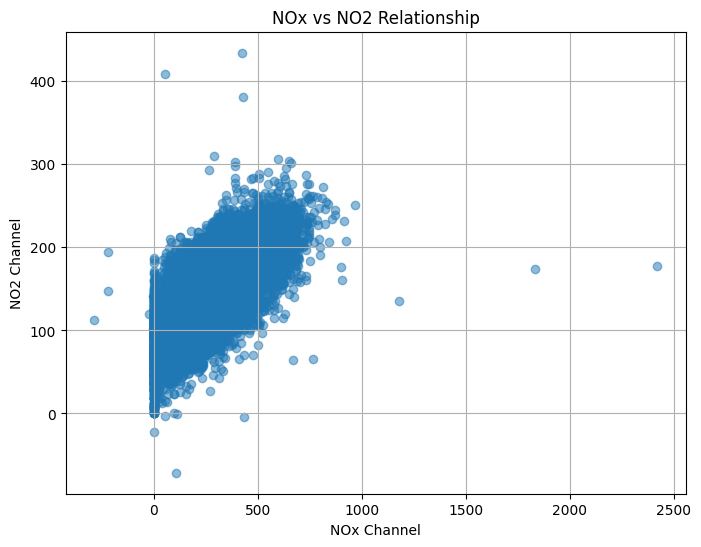

In [ ]:
# RELATIONSHIP VISUALIZATION

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(
    train_df["NOx_Channel"],
    train_df["NO2_Channel"],
    alpha=0.5
)

plt.xlabel("NOx Channel")
plt.ylabel("NO2 Channel")
plt.title("NOx vs NO2 Relationship")

plt.grid(True)
plt.show()